
02 Modeling and Scenarios


This notebook loads the cleaned Facebook campaign dataset, creates weekly campaign-level
 aggregates, fits a campaign-level MMM-lite regression model, evaluates model behavior,# and simulates budget reallocation across campaigns.

In [47]:
# project roots and imports

from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

from src.model import (
    load_clean_data,
    build_weekly_campaign_dataset,
    build_campaign_model_dataset,
    fit_mmm_lite_campaign,
    export_model_artifacts,
)

from src.scenarios import (
    load_weekly_campaign_data,
    summarize_campaign_performance,
    simulate_campaign_budget_shift,
    save_campaign_scenario_results,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")

In [49]:
# paths

INPUT_PATH = Path("data/processed/final_dataset.csv")
FIG_DIR = Path("outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

SCENARIO_OUTPUT_PATH = Path("outputs/campaign_scenario_results.csv")

In [50]:
# load cleaned data

df = load_clean_data(INPUT_PATH)

print("Shape:", df.shape)
df.head()

Shape: (1274, 28)


,date,channel,campaign,impressions,clicks,conversions,cost,revenue,cpc,cpa,ctr,conversion_rate,roas,roi,profit_margin,cpc_calc,cpa_calc,ctr_calc,conversion_rate_calc,roas_calc,roi_calc,profit_margin_calc,profit,year,month,month_name,quarter,week_start
0,2023-11-01,Facebook,Best Sellers,75764,24390,3645,"27,534.3121","136,591.8130",1.1289,7.5540,0.3219,0.1494,4.9608,3.9608,0.7984,1.1289,7.5540,0.3219,0.1494,4.9608,3.9608,0.7984,"109,057.5008",2023,11,November,2023Q4,2023-10-30
1,2023-11-01,Facebook,Exclusive Offers,79882,27362,3402,"28,207.7826","142,821.7795",1.0309,8.2915,0.3425,0.1243,5.0632,4.0632,0.8025,1.0309,8.2915,0.3425,0.1243,5.0632,4.0632,0.8025,"114,613.9968",2023,11,November,2023Q4,2023-10-30
2,2023-11-01,Facebook,Flash Sale,82355,27350,4269,"28,519.9799","217,096.0091",1.0428,6.6807,0.3321,0.1561,7.6121,6.6121,0.8686,1.0428,6.6807,0.3321,0.1561,7.6121,6.6121,0.8686,"188,576.0291",2023,11,November,2023Q4,2023-10-30
3,2023-11-01,Facebook,Limited Edition,59532,20314,2456,"22,405.3876","74,248.4349",1.1030,9.1227,0.3412,0.1209,3.3139,2.3139,0.6982,1.1030,9.1227,0.3412,0.1209,3.3139,2.3139,0.6982,"51,843.0473",2023,11,November,2023Q4,2023-10-30
4,2023-11-01,Facebook,Must-Haves,76115,23283,4124,"30,655.0915","282,509.8398",1.3166,7.4333,0.3059,0.1771,9.2158,8.2158,0.8915,1.3166,7.4333,0.3059,0.1771,9.2158,8.2158,0.8915,"251,854.7483",2023,11,November,2023Q4,2023-10-30


In [51]:
# build weekly campaign dataset

weekly_campaign = build_weekly_campaign_dataset(df)
weekly_campaign.head()

,week_start,campaign,spend,revenue,conversions,clicks,impressions,roas,conversion_rate,ctr
0,2023-10-30,Best Sellers,"154,410.6947","754,784.2378",14474,120693,382866,4.8882,0.1199,0.3152
1,2023-10-30,Exclusive Offers,"112,796.1673","436,254.0930",10454,86348,282641,3.8676,0.1211,0.3055
2,2023-10-30,Flash Sale,"148,644.3235","882,944.0487",16114,120900,381694,5.9400,0.1333,0.3167
3,2023-10-30,Limited Edition,"104,726.8388","389,183.9825",9929,84647,265262,3.7162,0.1173,0.3191
4,2023-10-30,Must-Haves,"134,963.9094","614,240.7588",14035,99559,329460,4.5511,0.1410,0.3022


In [52]:
print("Weekly campaign dataset shape:", weekly_campaign.shape)
print("Weeks:", weekly_campaign["week_start"].nunique())
print("Campaigns:", weekly_campaign["campaign"].nunique())

Weekly campaign dataset shape: (189, 10)
Weeks: 27
Campaigns: 7


In [53]:
# weekly campaign checks

weekly_campaign.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
week_start,189,NaN,NaN,NaN,2024-01-29 00:00:00,2023-10-30 00:00:00,2023-12-11 00:00:00,2024-01-29 00:00:00,2024-03-18 00:00:00,2024-04-29 00:00:00,NaN
campaign,189,7,Best Sellers,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
spend,189.0000,NaN,NaN,NaN,"165,281.9630","40,363.6321","148,079.3869","165,920.6366","188,773.0613","269,326.7944","36,715.6990"
revenue,189.0000,NaN,NaN,NaN,"788,434.5849","131,252.6658","664,363.5553","802,172.4709","919,649.9599","1,454,406.0143","214,358.5520"
conversions,189.0000,NaN,NaN,NaN,"15,739.1429","3,869.0000","14,027.0000","15,924.0000","18,285.0000","24,327.0000","3,569.3969"
clicks,189.0000,NaN,NaN,NaN,"130,272.5556","30,751.0000","118,750.0000","131,784.0000","149,912.0000","195,387.0000","28,442.5363"
impressions,189.0000,NaN,NaN,NaN,"423,248.2011","103,481.0000","385,791.0000","423,551.0000","480,934.0000","597,549.0000","88,923.7985"
roas,189.0000,NaN,NaN,NaN,4.7832,2.1807,4.1192,4.8047,5.3094,7.8950,0.9001
conversion_rate,189.0000,NaN,NaN,NaN,0.1213,0.0902,0.1123,0.1217,0.1302,0.1602,0.0133
ctr,189.0000,NaN,NaN,NaN,0.3074,0.2627,0.2976,0.3077,0.3175,0.3442,0.0162


In [54]:
weekly_campaign.isna().sum().sort_values(ascending=False)

week_start         0
campaign           0
spend              0
revenue            0
conversions        0
clicks             0
impressions        0
roas               0
conversion_rate    0
ctr                0
dtype: int64

In [55]:
# campaign performance summary 

campaign_perf = summarize_campaign_performance(weekly_campaign)
campaign_perf

,campaign,spend,revenue,conversions,clicks,roas,conversion_rate
2,Flash Sale,"4,945,382.1416","24,687,901.5155",475114,3901175,4.9921,0.1218
6,Trending Now,"3,565,017.5124","17,454,684.4558",340213,2818680,4.8961,0.1207
0,Best Sellers,"5,346,108.2579","26,019,977.1383",510791,4237876,4.8671,0.1205
5,New Arrivals,"4,189,149.7696","20,189,678.5135",400647,3311466,4.8195,0.1210
1,Exclusive Offers,"3,996,545.9680","18,622,342.8275",374187,3136484,4.6596,0.1193
4,Must-Haves,"4,753,320.7389","22,078,101.1278",452333,3729760,4.6448,0.1213
3,Limited Edition,"4,442,766.6170","19,961,450.9620",421413,3486072,4.4930,0.1209


/var/folders/3v/7tw8ds4112319zm34xbm40vr0000gn/T/ipykernel_72555/821224914.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=campaign_perf, x="campaign", y="roas", order=order, palette="viridis")


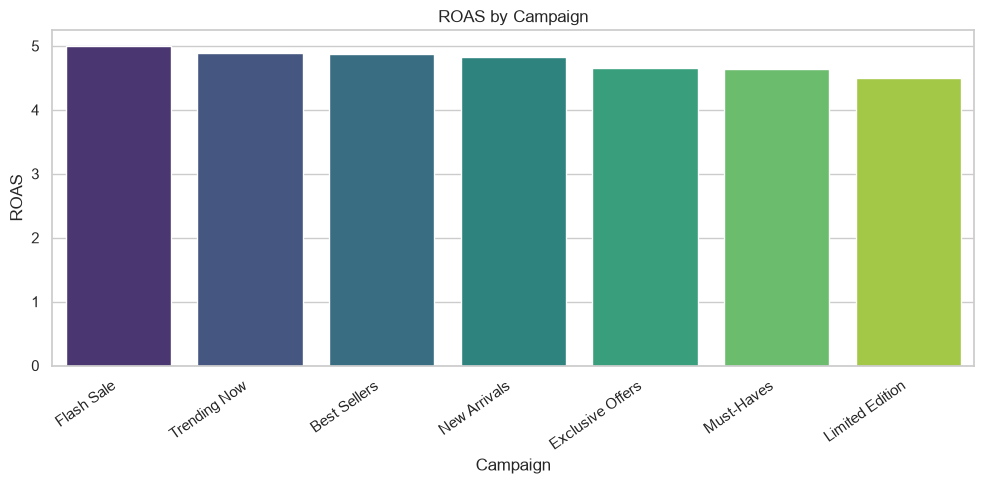

In [56]:
# campaign ROAS plot

plt.figure(figsize=(10, 5))
order = campaign_perf.sort_values("roas", ascending=False)["campaign"]
sns.barplot(data=campaign_perf, x="campaign", y="roas", order=order, palette="viridis")
plt.title("ROAS by Campaign")
plt.xlabel("Campaign")
plt.ylabel("ROAS")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "roas_by_campaign.png", dpi=150)
plt.show()

/var/folders/3v/7tw8ds4112319zm34xbm40vr0000gn/T/ipykernel_72555/999229814.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=campaign_perf, x="campaign", y="spend", order=spend_order, palette="Blues_r", ax=axes[0])
/var/folders/3v/7tw8ds4112319zm34xbm40vr0000gn/T/ipykernel_72555/999229814.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=campaign_perf, x="campaign", y="revenue", order=rev_order, palette="Greens_r", ax=axes[1])


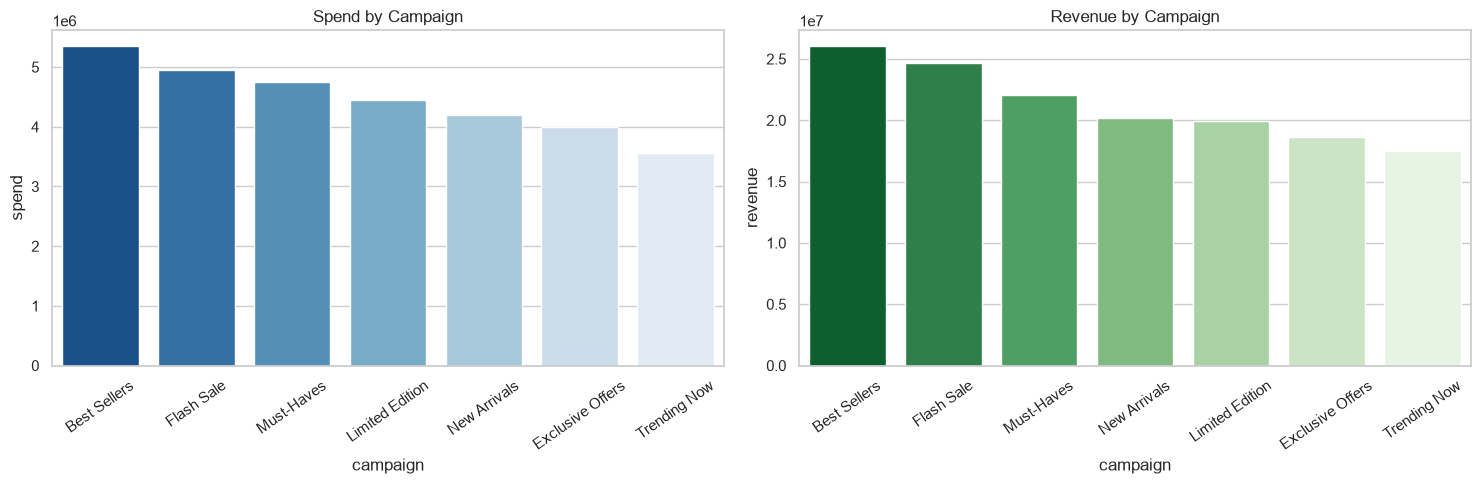

In [57]:
# campgin spend and revenue plot

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

spend_order = campaign_perf.sort_values("spend", ascending=False)["campaign"]
sns.barplot(data=campaign_perf, x="campaign", y="spend", order=spend_order, palette="Blues_r", ax=axes[0])
axes[0].set_title("Spend by Campaign")
axes[0].tick_params(axis="x", rotation=35)

rev_order = campaign_perf.sort_values("revenue", ascending=False)["campaign"]
sns.barplot(data=campaign_perf, x="campaign", y="revenue", order=rev_order, palette="Greens_r", ax=axes[1])
axes[1].set_title("Revenue by Campaign")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.savefig(FIG_DIR / "campaign_spend_revenue.png", dpi=150)
plt.show()

In [58]:
# build campaign model dataset

model_df = build_campaign_model_dataset(weekly_campaign)
model_df.head()

,week_start,spend_best_sellers,spend_exclusive_offers,spend_flash_sale,spend_limited_edition,spend_must_haves,spend_new_arrivals,spend_trending_now,revenue,time_index
0,2023-10-30,"154,410.6947","112,796.1673","148,644.3235","104,726.8388","134,963.9094","115,449.1139","105,594.2000","4,069,767.0941",0
1,2023-11-06,"204,794.7340","151,884.5219","167,990.8622","157,737.3847","180,235.5513","153,437.5396","159,447.0122","5,717,231.2438",1
2,2023-11-13,"150,957.0684","141,602.9027","184,660.0237","147,480.3764","148,079.3869","157,758.8606","104,127.4579","5,384,716.3857",2
3,2023-11-20,"198,569.7098","158,413.6726","205,853.6463","161,342.8188","182,235.0404","158,568.8834","105,007.4113","5,787,608.2731",3
4,2023-11-27,"242,328.4639","158,410.8241","236,292.6152","180,161.8099","188,773.0613","188,852.3602","128,203.2023","6,424,822.2585",4


In [59]:
model_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   week_start              27 non-null     datetime64[us]
 1   spend_best_sellers      27 non-null     float64       
 2   spend_exclusive_offers  27 non-null     float64       
 3   spend_flash_sale        27 non-null     float64       
 4   spend_limited_edition   27 non-null     float64       
 5   spend_must_haves        27 non-null     float64       
 6   spend_new_arrivals      27 non-null     float64       
 7   spend_trending_now      27 non-null     float64       
 8   revenue                 27 non-null     float64       
 9   time_index              27 non-null     int64         
dtypes: datetime64[us](1), float64(8), int64(1)
memory usage: 2.2 KB


In [60]:
# fit campaign level MMM lite model

model, preds, metrics, coef_df = fit_mmm_lite_campaign(model_df)
metrics

{'r2': 0.7507480444248227, 'mae': 379235.9968065883}

In [61]:
# export model artifacts

export_model_artifacts(weekly_campaign, model_df, coef_df)
coef_df

,feature,coefficient
7,time_index,"30,810.3877"
2,spend_flash_sale,24.2317
4,spend_must_haves,18.1004
1,spend_exclusive_offers,12.2252
6,spend_trending_now,1.4181
5,spend_new_arrivals,-0.8773
0,spend_best_sellers,-8.9924
3,spend_limited_edition,-13.0072


In [62]:
# add predictions for evaluation

results_df = model_df.copy()
results_df["predicted_revenue"] = preds
results_df["residual"] = results_df["revenue"] - results_df["predicted_revenue"]
results_df.head()

,week_start,spend_best_sellers,spend_exclusive_offers,spend_flash_sale,spend_limited_edition,spend_must_haves,spend_new_arrivals,spend_trending_now,revenue,time_index,predicted_revenue,residual
0,2023-10-30,"154,410.6947","112,796.1673","148,644.3235","104,726.8388","134,963.9094","115,449.1139","105,594.2000","4,069,767.0941",0,"4,275,230.8193","-205,463.7252"
1,2023-11-06,"204,794.7340","151,884.5219","167,990.8622","157,737.3847","180,235.5513","153,437.5396","159,447.0122","5,717,231.2438",1,"4,972,593.7672","744,637.4767"
2,2023-11-13,"150,957.0684","141,602.9027","184,660.0237","147,480.3764","148,079.3869","157,758.8606","104,127.4579","5,384,716.3857",2,"5,234,890.9477","149,825.4380"
3,2023-11-20,"198,569.7098","158,413.6726","205,853.6463","161,342.8188","182,235.0404","158,568.8834","105,007.4113","5,787,608.2731",3,"5,995,080.7128","-207,472.4397"
4,2023-11-27,"242,328.4639","158,410.8241","236,292.6152","180,161.8099","188,773.0613","188,852.3602","128,203.2023","6,424,822.2585",4,"6,249,835.2133","174,987.0452"


In [64]:
# model evaluation
mse = mean_squared_error(results_df["revenue"],
                         results_df["predicted_revenue"])
rmse = np.sqrt(mse)

evaluation_df = pd.DataFrame({
    "metric": ["r2", "mae", "rmse"],
    "value": [metrics["r2"], metrics["mae"], rmse]
})

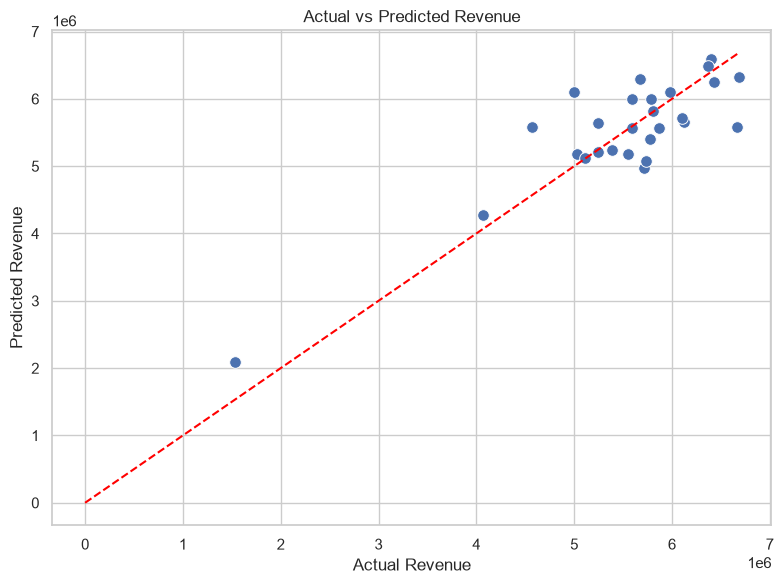

In [65]:
# actual vs preducted revenue

plt.figure(figsize=(8, 6))
sns.scatterplot(data=results_df, x="revenue", y="predicted_revenue", s=70)
max_val = max(results_df["revenue"].max(), results_df["predicted_revenue"].max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--")
plt.title("Actual vs Predicted Revenue")
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.tight_layout()
plt.savefig(FIG_DIR / "actual_vs_predicted_revenue_campaign_model.png", dpi=150)
plt.show()

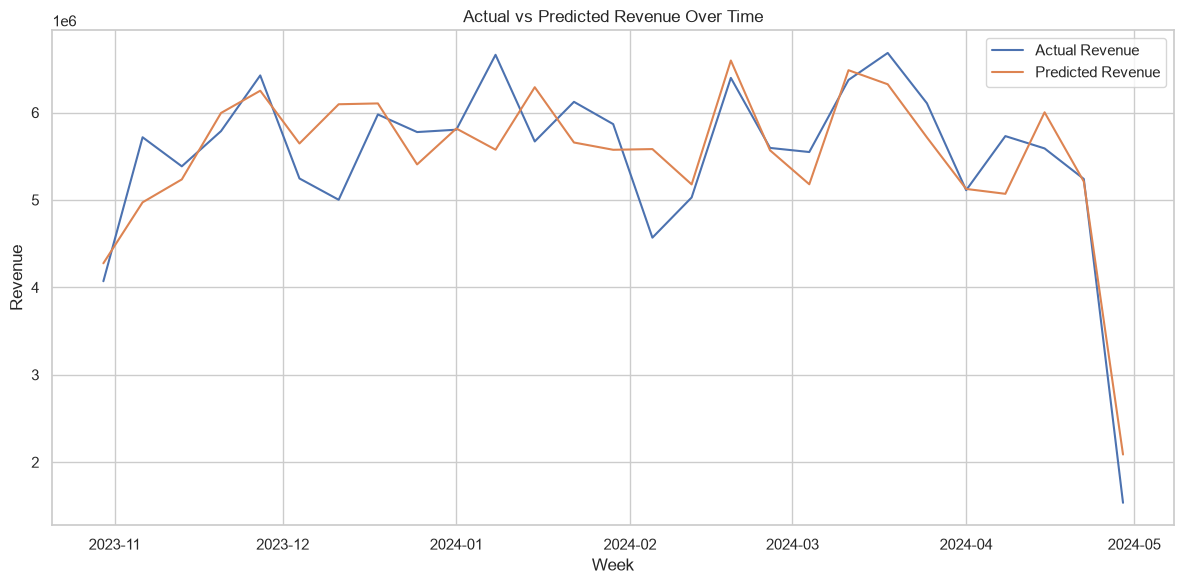

In [66]:
# revenue over timeL actual vs predicted

plt.figure(figsize=(12, 6))
sns.lineplot(data=results_df, x="week_start", y="revenue", label="Actual Revenue")
sns.lineplot(data=results_df, x="week_start", y="predicted_revenue", label="Predicted Revenue")
plt.title("Actual vs Predicted Revenue Over Time")
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig(FIG_DIR / "actual_vs_predicted_over_time_campaign_model.png", dpi=150)
plt.show()

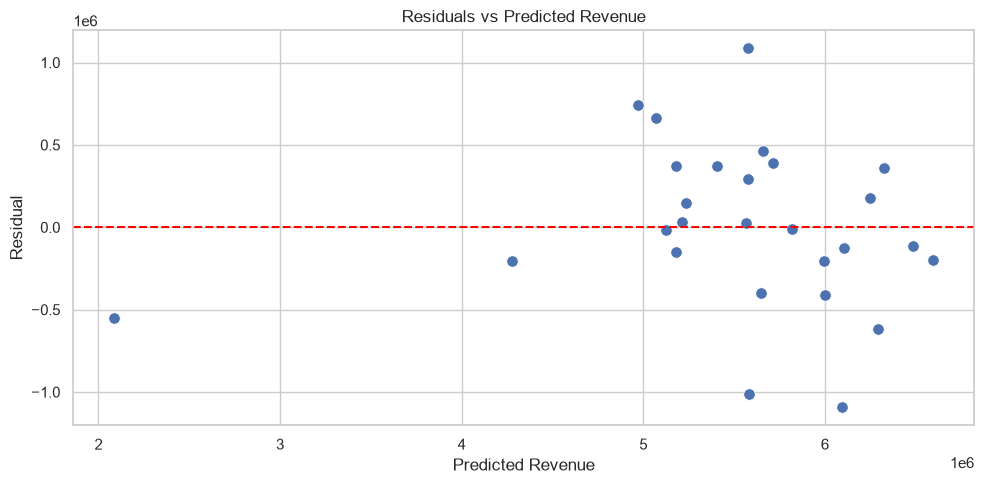

In [67]:
# residual plot

plt.figure(figsize=(10, 5))
sns.scatterplot(data=results_df, x="predicted_revenue", y="residual", s=70)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals vs Predicted Revenue")
plt.xlabel("Predicted Revenue")
plt.ylabel("Residual")
plt.tight_layout()
plt.savefig(FIG_DIR / "residuals_vs_predicted_campaign_model.png", dpi=150)
plt.show()

In [68]:
coef_df

,feature,coefficient
7,time_index,"30,810.3877"
2,spend_flash_sale,24.2317
4,spend_must_haves,18.1004
1,spend_exclusive_offers,12.2252
6,spend_trending_now,1.4181
5,spend_new_arrivals,-0.8773
0,spend_best_sellers,-8.9924
3,spend_limited_edition,-13.0072


In [69]:
# campaign spend coefficiens only

spend_coef_df = coef_df[coef_df["feature"].str.startswith("spend_")].copy()
spend_coef_df

,feature,coefficient
2,spend_flash_sale,24.2317
4,spend_must_haves,18.1004
1,spend_exclusive_offers,12.2252
6,spend_trending_now,1.4181
5,spend_new_arrivals,-0.8773
0,spend_best_sellers,-8.9924
3,spend_limited_edition,-13.0072


/var/folders/3v/7tw8ds4112319zm34xbm40vr0000gn/T/ipykernel_72555/3201762510.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


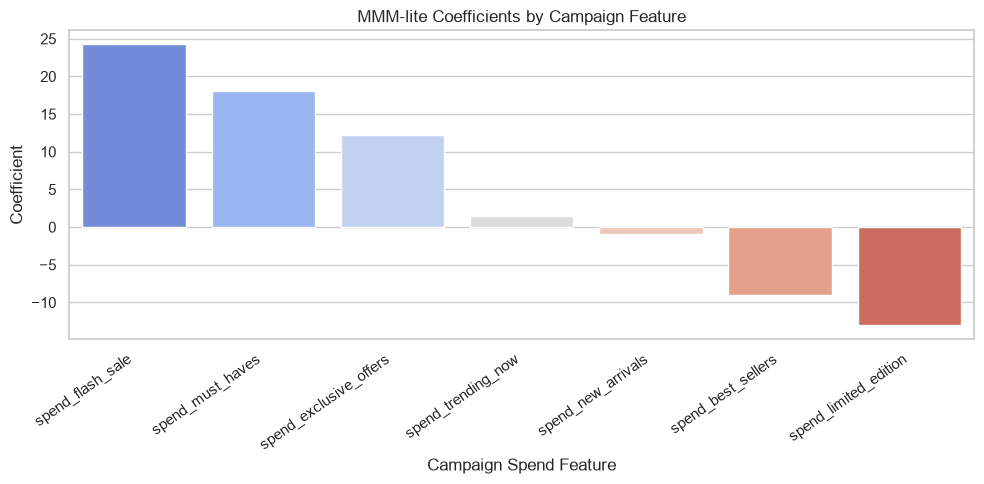

In [70]:
# coefficient chart

plt.figure(figsize=(10, 5))
order = spend_coef_df.sort_values("coefficient", ascending=False)["feature"]
sns.barplot(
    data=spend_coef_df,
    x="feature",
    y="coefficient",
    order=order,
    palette="coolwarm"
)
plt.title("MMM-lite Coefficients by Campaign Feature")
plt.xlabel("Campaign Spend Feature")
plt.ylabel("Coefficient")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "campaign_coefficients.png", dpi=150)
plt.show()

In [71]:
# run campaign scenario

scenario_df = simulate_campaign_budget_shift(
    campaign_perf,
    shift_pct=0.10,
    top_n=2,
    bottom_n=2,
)

save_campaign_scenario_results(scenario_df, SCENARIO_OUTPUT_PATH)
scenario_df

,campaign,current_spend,scenario_spend,roas,conversion_rate,projected_revenue_current,projected_revenue_scenario,projected_revenue_lift
0,Flash Sale,"4,945,382.1416","5,405,186.5094",4.9921,0.1218,"24,687,901.5155","26,983,296.4159","2,295,394.9004"
1,Trending Now,"3,565,017.5124","4,024,821.8802",4.8961,0.1207,"17,454,684.4558","19,705,932.9065","2,251,248.4506"
2,Best Sellers,"5,346,108.2579","5,346,108.2579",4.8671,0.1205,"26,019,977.1383","26,019,977.1383",0.0000
3,New Arrivals,"4,189,149.7696","4,189,149.7696",4.8195,0.1210,"20,189,678.5135","20,189,678.5135",0.0000
4,Exclusive Offers,"3,996,545.9680","3,996,545.9680",4.6596,0.1193,"18,622,342.8275","18,622,342.8275",0.0000
6,Limited Edition,"4,442,766.6170","3,998,489.9553",4.4930,0.1209,"19,961,450.9620","17,965,305.8658","-1,996,145.0962"
5,Must-Haves,"4,753,320.7389","4,277,988.6650",4.6448,0.1213,"22,078,101.1278","19,870,291.0151","-2,207,810.1128"


In [72]:
# scenario totals

scenario_summary = pd.DataFrame({
    "metric": [
        "total_current_spend",
        "total_scenario_spend",
        "total_projected_revenue_current",
        "total_projected_revenue_scenario",
        "total_projected_revenue_lift",
    ],
    "value": [
        scenario_df["current_spend"].sum(),
        scenario_df["scenario_spend"].sum(),
        scenario_df["projected_revenue_current"].sum(),
        scenario_df["projected_revenue_scenario"].sum(),
        scenario_df["projected_revenue_lift"].sum(),
    ]
})

scenario_summary

,metric,value
0,total_current_spend,"31,238,291.0055"
1,total_scenario_spend,"31,238,291.0055"
2,total_projected_revenue_current,"149,014,136.5404"
3,total_projected_revenue_scenario,"149,356,824.6824"
4,total_projected_revenue_lift,"342,688.1421"


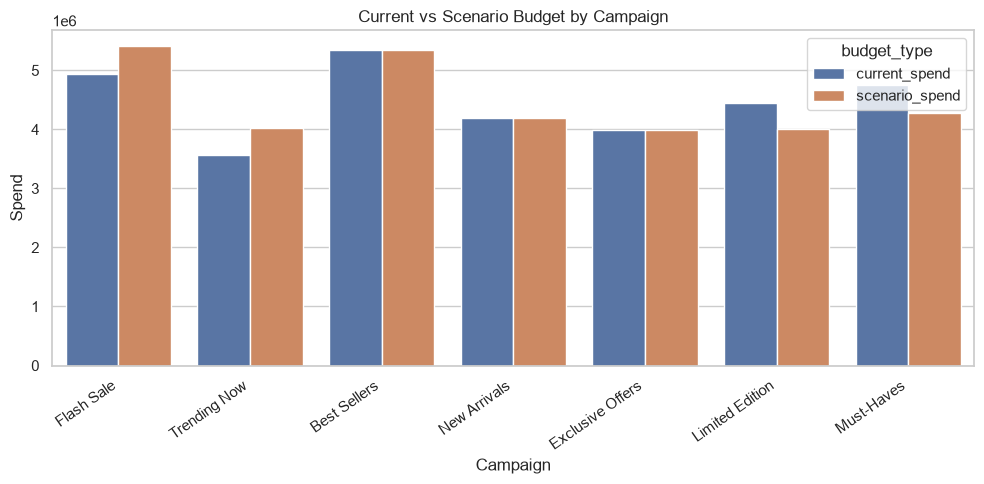

In [73]:
# budget comparison plot

scenario_plot_df = scenario_df.melt(
    id_vars="campaign",
    value_vars=["current_spend", "scenario_spend"],
    var_name="budget_type",
    value_name="spend"
)

plt.figure(figsize=(10, 5))
sns.barplot(data=scenario_plot_df, x="campaign", y="spend", hue="budget_type")
plt.title("Current vs Scenario Budget by Campaign")
plt.xlabel("Campaign")
plt.ylabel("Spend")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "campaign_budget_comparison.png", dpi=150)
plt.show()

/var/folders/3v/7tw8ds4112319zm34xbm40vr0000gn/T/ipykernel_72555/2848375169.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


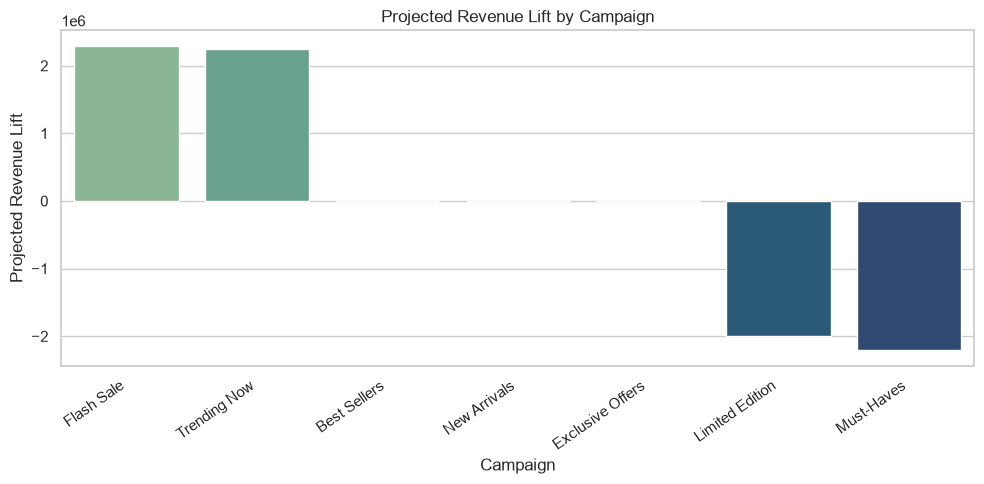

In [74]:
# projected revnue lift by campaign
plt.figure(figsize=(10, 5))
order = scenario_df.sort_values("projected_revenue_lift", ascending=False)["campaign"]
sns.barplot(
    data=scenario_df,
    x="campaign",
    y="projected_revenue_lift",
    order=order,
    palette="crest"
)
plt.title("Projected Revenue Lift by Campaign")
plt.xlabel("Campaign")
plt.ylabel("Projected Revenue Lift")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "projected_revenue_lift_by_campaign.png", dpi=150)
plt.show()

In [75]:
# export notebook outputs

campaign_perf.to_csv("outputs/campaign_performance_summary.csv", index=False)
results_df.to_csv("outputs/campaign_model_results_with_predictions.csv", index=False)
evaluation_df.to_csv("outputs/campaign_model_evaluation_metrics.csv", index=False)
scenario_summary.to_csv("outputs/campaign_scenario_summary.csv", index=False)

In [76]:
print("Top campaigns by ROAS:")
display(campaign_perf.sort_values("roas", ascending=False).head(3))

print("Largest positive campaign coefficients:")
display(spend_coef_df.sort_values("coefficient", ascending=False).head(3))

print("Scenario impact summary:")
display(scenario_summary)

Top campaigns by ROAS:


,campaign,spend,revenue,conversions,clicks,roas,conversion_rate
2,Flash Sale,"4,945,382.1416","24,687,901.5155",475114,3901175,4.9921,0.1218
6,Trending Now,"3,565,017.5124","17,454,684.4558",340213,2818680,4.8961,0.1207
0,Best Sellers,"5,346,108.2579","26,019,977.1383",510791,4237876,4.8671,0.1205


Largest positive campaign coefficients:


,feature,coefficient
2,spend_flash_sale,24.2317
4,spend_must_haves,18.1004
1,spend_exclusive_offers,12.2252


Scenario impact summary:


,metric,value
0,total_current_spend,"31,238,291.0055"
1,total_scenario_spend,"31,238,291.0055"
2,total_projected_revenue_current,"149,014,136.5404"
3,total_projected_revenue_scenario,"149,356,824.6824"
4,total_projected_revenue_lift,"342,688.1421"
